<a href="https://colab.research.google.com/github/2303a51060Nirnaya/High_performance_computing-Hcp-/blob/main/weather_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get update
!apt-get install -y build-essential libomp-dev

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.9ubuntu3).
libomp-dev is already the newest 

In [ ]:
%%writefile serial_weather.c
#include <stdio.h>
#include <stdlib.h>
#include <time.h>

int main() {
    int n = 1000;
    FILE *f = fopen("serial_output.txt", "w");

    srand(time(0));
    clock_t start = clock();

    for(int i = 0; i < n; i++) {
        float temp = (rand() % 50) + (rand() % 100)/100.0;
        fprintf(f, "%f\n", temp);
    }

    clock_t end = clock();
    double time_taken = ((double)(end - start))/CLOCKS_PER_SEC;

    FILE *t = fopen("serial_time.txt", "w");
    fprintf(t, "%f", time_taken);

    fclose(f); fclose(t);
    return 0;
}

Overwriting serial_weather.c


In [ ]:
%%writefile parallel_weather.c
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>

int main() {
    int n = 1000;
    FILE *f = fopen("parallel_output.txt", "w");

    double start = omp_get_wtime();

    #pragma omp parallel for
    for(int i = 0; i < n; i++) {
        float temp = (rand() % 50) + (rand() % 100)/100.0;

        #pragma omp critical
        fprintf(f, "%f\n", temp);
    }

    double end = omp_get_wtime();
    double time_taken = end - start;

    FILE *t = fopen("parallel_time.txt", "w");
    fprintf(t, "%f", time_taken);

    fclose(f); fclose(t);
    return 0;
}

Overwriting parallel_weather.c


In [ ]:
!gcc serial_weather.c -o serial
!gcc -fopenmp parallel_weather.c -o parallel

!./serial
!./parallel

In [ ]:
!pip install matplotlib

In [ ]:
import matplotlib.pyplot as plt

def read_file(file):
    data = []
    with open(file, 'r') as f:
        for line in f:
            try:
                data.append(float(line.strip()))
            except:
                pass
    return data

serial = read_file("serial_output.txt")
parallel = read_file("parallel_output.txt")

with open("serial_time.txt") as f:
    s_time = float(f.read())

with open("parallel_time.txt") as f:
    p_time = float(f.read())

diff = [abs(serial[i] - parallel[i]) for i in range(min(len(serial), len(parallel)))]
accuracy = 100 - (sum(diff)/len(diff))


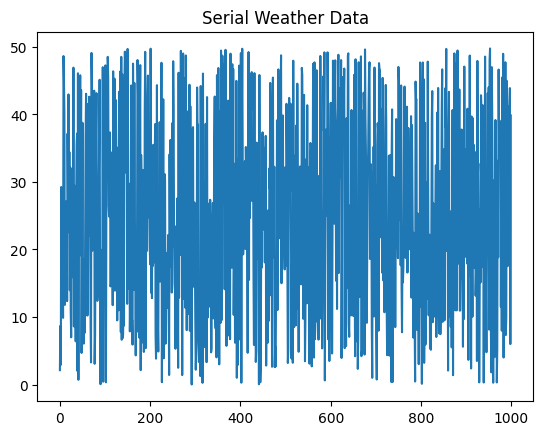

In [ ]:
plt.figure()
plt.plot(serial)
plt.title("Serial Weather Data")
plt.show()

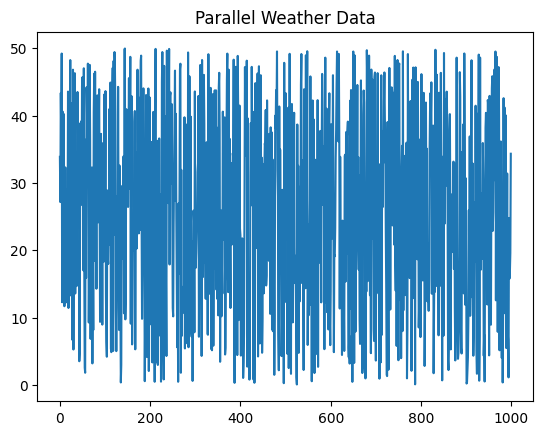

In [ ]:
plt.figure()
plt.plot(parallel)
plt.title("Parallel Weather Data")
plt.show()

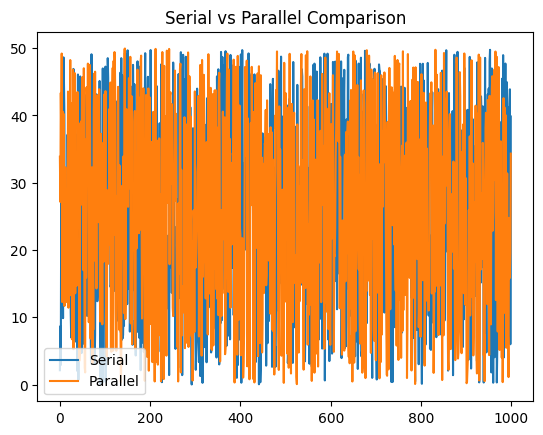

In [ ]:
plt.figure()
plt.plot(serial, label="Serial")
plt.plot(parallel, label="Parallel")
plt.legend()
plt.title("Serial vs Parallel Comparison")
plt.show()

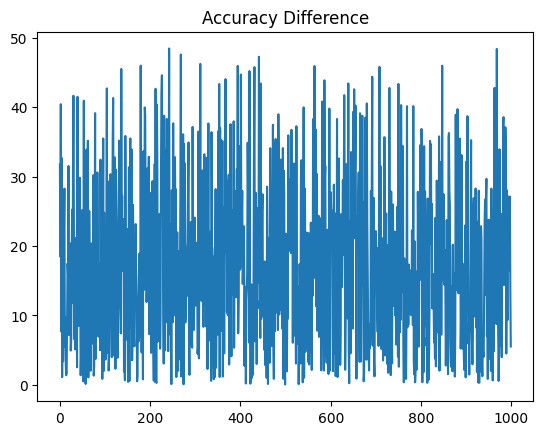

In [ ]:
plt.figure()
plt.plot(diff)
plt.title("Accuracy Difference")
plt.show()

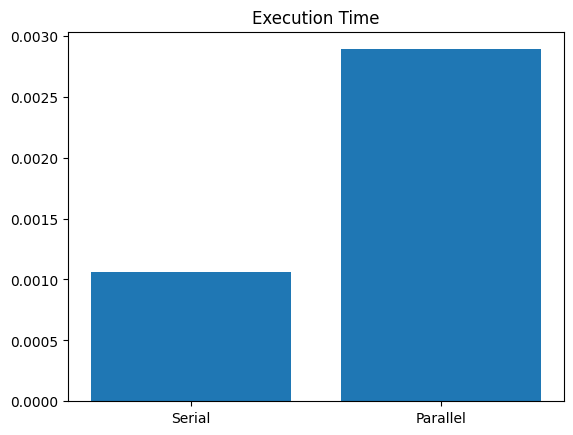

In [ ]:
plt.figure()
plt.bar(["Serial", "Parallel"], [s_time, p_time])
plt.title("Execution Time")
plt.show()

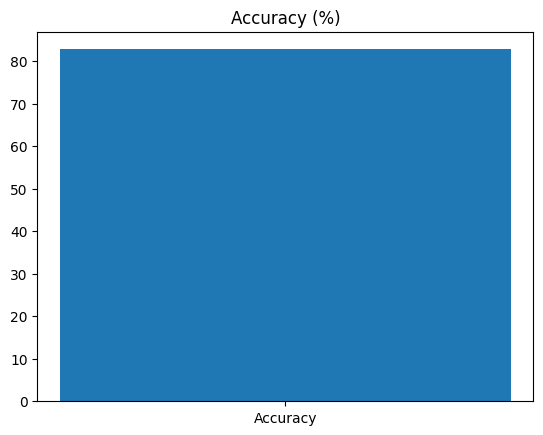

In [ ]:
plt.figure()
plt.bar(["Accuracy"], [accuracy])
plt.title("Accuracy (%)")
plt.show()

In [ ]:
from IPython.display import display, HTML

html = f"""
<div style="font-family:Arial; padding:20px">
<h1 style="color:blue;">Weather Simulation Dashboard</h1>

<h2>📊 Performance Summary</h2>
<ul>
<li><b>Serial Time:</b> {s_time:.4f} sec</li>
<li><b>Parallel Time:</b> {p_time:.4f} sec</li>
<li><b>Accuracy:</b> {accuracy:.2f}%</li>
</ul>

<h3>📈 Graphs Generated</h3>
<ul>
<li>Serial Graph</li>
<li>Parallel Graph</li>
<li>Comparison Graph</li>
<li>Accuracy Graph</li>
<li>Time Graph</li>
</ul>

<p style="color:green;">Project successfully executed 🎉</p>
</div>
"""

display(HTML(html))